In [1]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

In [2]:
folder_path = r"C:\Users\sorra\OneDrive\2026-09-01 @ DADS 5001 Tools\data"
print(os.listdir(folder_path))

['2024_pudb_sf_ctf_fhlmc.csv', '2024_pudb_sf_ctf_fnma.csv']


In [3]:
# Find all CSV files
csv_files = glob.glob(folder_path + r"\*.csv")

# Read each CSV into a list
dataframes = []

for file in csv_files:
    df = pd.read_csv(file)
    dataframes.append(df)

# Merge all CSVs into ONE pandas DataFrame
dataset = pd.concat(dataframes, ignore_index=True)

dataset

,enterprise,record_num_sf_ctf,state_fips,cbsa_metro_code,county_fips,tract_2020,tract_minority_pct,tract_income_med,ami_local,tract_income_ratio,...,period_intro_rate,mh_land_interest,property_value,tract_rural,county_lower_ms_delta,county_mid_appalachia,county_persistent_poverty,area_concentrated_poverty,area_high_opp,tract_colonias
0,2,20000001,48,19100,439,113932,51.83,141250,99957,1.4131,...,999,5,535000,0,0,0,0,0,1,0
1,2,20000002,48,19100,439,113946,46.18,114286,99957,1.1434,...,999,5,415000,0,0,0,0,0,1,0
2,2,20000003,37,39580,183,52807,69.51,80605,113293,0.7115,...,999,5,415000,0,0,0,0,0,0,0
3,2,20000004,42,38300,3,151700,23.83,114601,96434,1.1884,...,999,5,255000,0,0,0,0,0,0,0
4,2,20000005,17,16980,31,823001,35.67,69542,106055,0.6557,...,999,5,305000,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010243,1,10982109,47,99999,35,970101,6.87,82699,66883,1.2365,...,999,5,345000,1,0,1,0,0,1,0
2010244,1,10982110,4,38060,13,112202,87.52,58182,93191,0.6243,...,999,5,375000,0,0,0,0,1,0,0
2010245,1,10982111,26,19820,147,620000,35.11,49893,93779,0.5320,...,999,5,175000,0,0,0,0,1,0,0
2010246,1,10982112,25,12700,1,14900,11.33,131522,118599,1.1090,...,999,5,1255000,0,0,0,0,0,1,0


In [4]:
dataset.columns

Index(['enterprise', 'record_num_sf_ctf', 'state_fips', 'cbsa_metro_code',
       'county_fips', 'tract_2020', 'tract_minority_pct', 'tract_income_med',
       'ami_local', 'tract_income_ratio', 'income_annual', 'ami_hud',
       'income_ratio', 'upb_acq', 'purpose_ctf', 'fed_guarantee_ctf',
       'borr_num', 'fthb', 'race1_borr', 'race2_borr', 'race3_borr',
       'race4_borr', 'race5_borr', 'ethnicity_borr', 'race1_coborr',
       'race2_coborr', 'race3_coborr', 'race4_coborr', 'race5_coborr',
       'ethnicity_coborr', 'sex_borr', 'sex_coborr', 'age_borr_cat',
       'age_coborr_cat', 'occupancy_sf_ctf', 'rate_spread', 'hoepa',
       'property_type', 'lien_status', 'age_borr_62_cat', 'age_coborr_62_cat',
       'ltv', 'same_year_acq', 'term_orig', 'units_num', 'rate_orig',
       'upb_orig', 'preapproval', 'channel_apply', 'aus', 'score_borr_model',
       'score_coborr_model', 'dti_cat', 'points', 'period_intro_rate',
       'mh_land_interest', 'property_value', 'tract_rural',
  

In [5]:
#DTI CATEGORY MAPPING

def dti_name(x):
    if x == 10:
        return "Less than 20 percent"
    elif x == 20:
        return "20 to less than 30 percent"
    elif x == 30:
        return "30 to less than 36 percent"
    elif 36 <= x <= 49:
        return "36 to less than 50 percent"
    elif x == 50:
        return "50 to 60 percent"
    elif x == 60:
        return "Greater than 60 percent"
    elif x == 99:
        return "Not available"
    else:
        return "Unknown"

dataset["dti_cat_name"] = dataset["dti_cat"].apply(dti_name)

In [6]:
#dataset

In [7]:
#DTI BURDEN

#The key cutoff I'd use is 36%.

#Below 36% → Low burden: Debt payments consume less than roughly one-third of income. 
#There is comparatively more income available for other expenses.
#36% to <50% → Medium burden: Debt is taking a noticeably larger portion of income. 
#The borrower has less financial flexibility.
#50%+ → High burden: At least half of income is going toward debt obligations, 
#which represents a substantial debt burden and leaves considerably less income for other expenses.



def dti_burden(x):
    if x in [10, 20, 30]:
        return "Low burden"
    elif 36 <= x <= 49:
        return "Medium burden"
    elif x in [50, 60]:
        return "High burden"
    elif x == 99:
        return "Not available"
    else:
        return "Unknown"

dataset["dti_burden"] = dataset["dti_cat"].apply(dti_burden)

In [8]:
#dataset

In [9]:
#INCOME CATEGORY

#80% is a particularly meaningful cutoff because income below 80% of the area's median 
#is commonly treated as a lower-income level in housing-policy contexts.

def income_category(x):
    if x == 9999:
        return "Not available"
    elif x < 0.80:
        return "Low income"
    elif x < 1.20:
        return "Medium income"
    else:
        return "High income"

dataset["income_category"] = dataset["income_ratio"].apply(income_category)

In [10]:
dataset["enterprise_name"] = dataset["enterprise"].map({
    1: "Fannie Mae",
    2: "Freddie Mac"
})

In [11]:
dataset.columns

Index(['enterprise', 'record_num_sf_ctf', 'state_fips', 'cbsa_metro_code',
       'county_fips', 'tract_2020', 'tract_minority_pct', 'tract_income_med',
       'ami_local', 'tract_income_ratio', 'income_annual', 'ami_hud',
       'income_ratio', 'upb_acq', 'purpose_ctf', 'fed_guarantee_ctf',
       'borr_num', 'fthb', 'race1_borr', 'race2_borr', 'race3_borr',
       'race4_borr', 'race5_borr', 'ethnicity_borr', 'race1_coborr',
       'race2_coborr', 'race3_coborr', 'race4_coborr', 'race5_coborr',
       'ethnicity_coborr', 'sex_borr', 'sex_coborr', 'age_borr_cat',
       'age_coborr_cat', 'occupancy_sf_ctf', 'rate_spread', 'hoepa',
       'property_type', 'lien_status', 'age_borr_62_cat', 'age_coborr_62_cat',
       'ltv', 'same_year_acq', 'term_orig', 'units_num', 'rate_orig',
       'upb_orig', 'preapproval', 'channel_apply', 'aus', 'score_borr_model',
       'score_coborr_model', 'dti_cat', 'points', 'period_intro_rate',
       'mh_land_interest', 'property_value', 'tract_rural',
  

In [12]:
dataset

,enterprise,record_num_sf_ctf,state_fips,cbsa_metro_code,county_fips,tract_2020,tract_minority_pct,tract_income_med,ami_local,tract_income_ratio,...,county_lower_ms_delta,county_mid_appalachia,county_persistent_poverty,area_concentrated_poverty,area_high_opp,tract_colonias,dti_cat_name,dti_burden,income_category,enterprise_name
0,2,20000001,48,19100,439,113932,51.83,141250,99957,1.4131,...,0,0,0,0,1,0,36 to less than 50 percent,Medium burden,High income,Freddie Mac
1,2,20000002,48,19100,439,113946,46.18,114286,99957,1.1434,...,0,0,0,0,1,0,20 to less than 30 percent,Low burden,High income,Freddie Mac
2,2,20000003,37,39580,183,52807,69.51,80605,113293,0.7115,...,0,0,0,0,0,0,36 to less than 50 percent,Medium burden,High income,Freddie Mac
3,2,20000004,42,38300,3,151700,23.83,114601,96434,1.1884,...,0,0,0,0,0,0,36 to less than 50 percent,Medium burden,Low income,Freddie Mac
4,2,20000005,17,16980,31,823001,35.67,69542,106055,0.6557,...,0,0,0,0,0,0,36 to less than 50 percent,Medium burden,Low income,Freddie Mac
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010243,1,10982109,47,99999,35,970101,6.87,82699,66883,1.2365,...,0,1,0,0,1,0,36 to less than 50 percent,Medium burden,Low income,Fannie Mae
2010244,1,10982110,4,38060,13,112202,87.52,58182,93191,0.6243,...,0,0,0,1,0,0,36 to less than 50 percent,Medium burden,Low income,Fannie Mae
2010245,1,10982111,26,19820,147,620000,35.11,49893,93779,0.5320,...,0,0,0,1,0,0,20 to less than 30 percent,Low burden,Low income,Fannie Mae
2010246,1,10982112,25,12700,1,14900,11.33,131522,118599,1.1090,...,0,0,0,0,1,0,36 to less than 50 percent,Medium burden,Low income,Fannie Mae


In [13]:
dataset

,enterprise,record_num_sf_ctf,state_fips,cbsa_metro_code,county_fips,tract_2020,tract_minority_pct,tract_income_med,ami_local,tract_income_ratio,...,county_lower_ms_delta,county_mid_appalachia,county_persistent_poverty,area_concentrated_poverty,area_high_opp,tract_colonias,dti_cat_name,dti_burden,income_category,enterprise_name
0,2,20000001,48,19100,439,113932,51.83,141250,99957,1.4131,...,0,0,0,0,1,0,36 to less than 50 percent,Medium burden,High income,Freddie Mac
1,2,20000002,48,19100,439,113946,46.18,114286,99957,1.1434,...,0,0,0,0,1,0,20 to less than 30 percent,Low burden,High income,Freddie Mac
2,2,20000003,37,39580,183,52807,69.51,80605,113293,0.7115,...,0,0,0,0,0,0,36 to less than 50 percent,Medium burden,High income,Freddie Mac
3,2,20000004,42,38300,3,151700,23.83,114601,96434,1.1884,...,0,0,0,0,0,0,36 to less than 50 percent,Medium burden,Low income,Freddie Mac
4,2,20000005,17,16980,31,823001,35.67,69542,106055,0.6557,...,0,0,0,0,0,0,36 to less than 50 percent,Medium burden,Low income,Freddie Mac
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010243,1,10982109,47,99999,35,970101,6.87,82699,66883,1.2365,...,0,1,0,0,1,0,36 to less than 50 percent,Medium burden,Low income,Fannie Mae
2010244,1,10982110,4,38060,13,112202,87.52,58182,93191,0.6243,...,0,0,0,1,0,0,36 to less than 50 percent,Medium burden,Low income,Fannie Mae
2010245,1,10982111,26,19820,147,620000,35.11,49893,93779,0.5320,...,0,0,0,1,0,0,20 to less than 30 percent,Low burden,Low income,Fannie Mae
2010246,1,10982112,25,12700,1,14900,11.33,131522,118599,1.1090,...,0,0,0,0,1,0,36 to less than 50 percent,Medium burden,Low income,Fannie Mae


In [14]:
dataset["fthb_name"] = np.where(
    dataset["fthb"] == 1,
    "First time",
    "Not first time"
)

In [15]:
dataset['borrower_type'] = np.where(
    dataset['borr_num'] == 1,
    'Single borrower',
    'With co-borrower'
)

In [16]:
age_mapping = {
    1: "Under 25",
    2: "25–34",
    3: "35–44",
    4: "45–54",
    5: "55–64",
    6: "65–74",
    7: "Over 74",
    9: "Not available"
}

dataset["age_category"] = dataset["age_borr_cat"].map(age_mapping)

In [17]:
dataset.columns

Index(['enterprise', 'record_num_sf_ctf', 'state_fips', 'cbsa_metro_code',
       'county_fips', 'tract_2020', 'tract_minority_pct', 'tract_income_med',
       'ami_local', 'tract_income_ratio', 'income_annual', 'ami_hud',
       'income_ratio', 'upb_acq', 'purpose_ctf', 'fed_guarantee_ctf',
       'borr_num', 'fthb', 'race1_borr', 'race2_borr', 'race3_borr',
       'race4_borr', 'race5_borr', 'ethnicity_borr', 'race1_coborr',
       'race2_coborr', 'race3_coborr', 'race4_coborr', 'race5_coborr',
       'ethnicity_coborr', 'sex_borr', 'sex_coborr', 'age_borr_cat',
       'age_coborr_cat', 'occupancy_sf_ctf', 'rate_spread', 'hoepa',
       'property_type', 'lien_status', 'age_borr_62_cat', 'age_coborr_62_cat',
       'ltv', 'same_year_acq', 'term_orig', 'units_num', 'rate_orig',
       'upb_orig', 'preapproval', 'channel_apply', 'aus', 'score_borr_model',
       'score_coborr_model', 'dti_cat', 'points', 'period_intro_rate',
       'mh_land_interest', 'property_value', 'tract_rural',
  

In [18]:
########### VISUALISATION ####################

In [19]:
# HOW LARGE ARE MORTGAGE CUSTOMERS # AND WHY WE SHOULD CARE

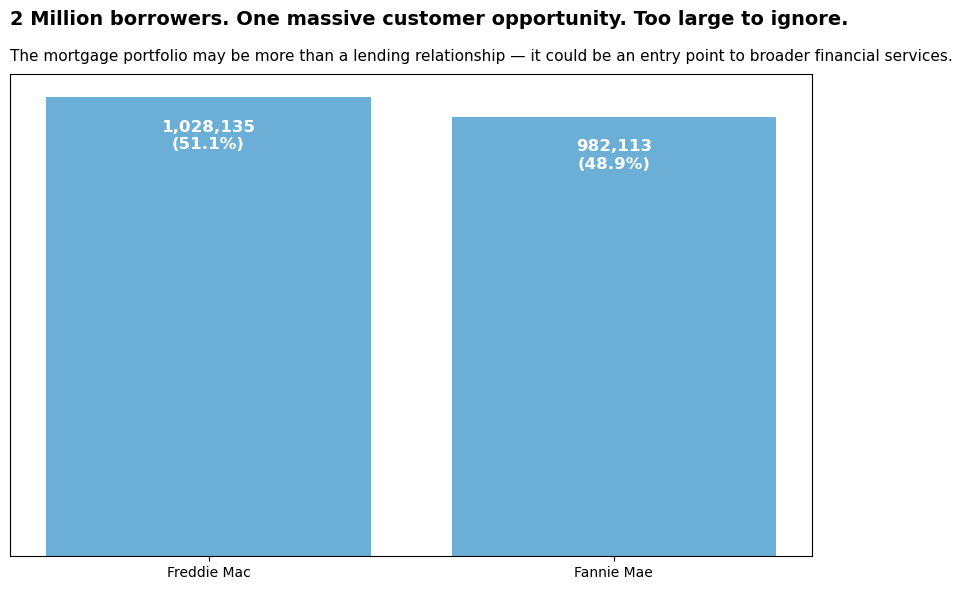

In [20]:
#1

# Count records for each enterprise
counts = dataset.groupby("enterprise_name")["record_num_sf_ctf"].count()

# Desired order
order = ["Freddie Mac", "Fannie Mae"]
counts = counts.reindex([x for x in order if x in counts.index])

# Calculate percentage
percentages = counts / counts.sum() * 100

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Create columns
bars = ax.bar(
    counts.index,
    counts.values,
    color="#6BAED6"
)

# Title
ax.set_title(
    "2 Million borrowers. One massive customer opportunity. Too large to ignore.",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=35
)

# Subtitle
ax.text(
    0,
    1.02,
    "The mortgage portfolio may be more than a lending relationship — it could be an entry point to broader financial services.",
    transform=ax.transAxes,
    fontsize=11,
    va="bottom"
)

# Remove Y-axis numbers and ticks
ax.tick_params(
    axis="y",
    left=False,
    labelleft=False
)

# Add count and percentage labels INSIDE both bars
for bar, count, pct in zip(
    bars, counts.values, percentages.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 0.95,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="top",
        color="white",
        fontweight="bold",
        fontsize=12
    )

plt.tight_layout()
plt.show()

In [21]:
# 1.2 Number of terms

def term_category(x):
    if x <= 180:
        return "Short-term"
    elif x <= 240:
        return "Medium-term"
    elif x > 240:
        return "Long-term"
    else:
        return "Not available"

dataset["term_category"] = dataset["term_orig"].apply(term_category)

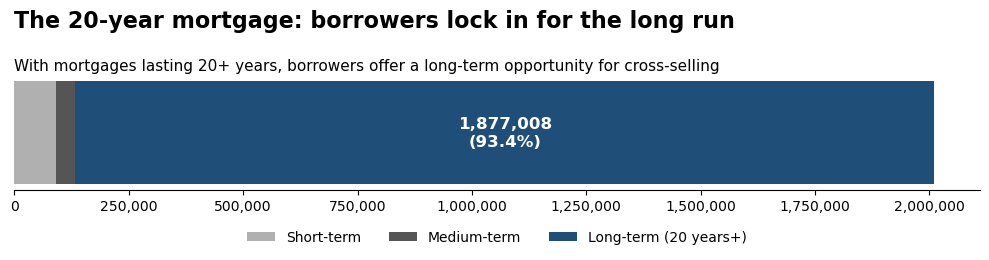

In [22]:
#2
#import pandas as pd
#import matplotlib.pyplot as plt

# ==============================
# 1. Create term category
# ==============================

def term_category(x):
    if x <= 180:
        return "Short-term"
    elif x <= 240:
        return "Medium-term"
    elif x > 240:
        return "Long-term (20 years+)"
    else:
        return "Not available"

dataset["term_category"] = dataset["term_orig"].apply(term_category)


# ==============================
# 2. Count records by category
# ==============================

counts = dataset.groupby("term_category")["record_num_sf_ctf"].count()

# Desired order
order = ["Short-term", "Medium-term", "Long-term (20 years+)"]

counts = counts.reindex(
    [x for x in order if x in counts.index]
)

# Calculate percentages
percentages = counts / counts.sum() * 100


# ==============================
# 3. Create horizontal stacked bar
# ==============================

fig, ax = plt.subplots(figsize=(10, 3))

# Colors:
# Short-term = gray
# Medium-term = light blue
# Long-term = green
colors = ["#B0B0B0", "#555555", "#1F4E79"]

left = 0

for category, count, pct, color in zip(
    counts.index,
    counts.values,
    percentages.values,
    colors
):

    ax.barh(
        ["Mortgage terms"],
        [count],
        left=left,
        color=color,
        label=category
    )

    # Label ONLY Long-term
    if category == "Long-term (20 years+)":
        ax.text(
            left + count / 2,
            0,
            f"{count:,}\n({pct:.1f}%)",
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
            fontsize=12
        )

    left += count


# ==============================
# 4. Title and subtitle
# ==============================

ax.set_title(
    "The 20-year mortgage: borrowers lock in for the long run",
    loc="left",
    fontsize=16,
    fontweight="bold",
    pad=35
)

ax.text(
    0,
    1.02,
    "With mortgages lasting 20+ years, borrowers offer a long-term opportunity for cross-selling",
    transform=ax.transAxes,
    fontsize=11,
    va="bottom"
)


# ==============================
# 5. Format chart
# ==============================

# Remove y-axis label/ticks
ax.set_yticks([])

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Remove x-axis scientific notation
ax.ticklabel_format(
    style="plain",
    axis="x"
)

# Add comma formatting to x-axis
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{int(x):,}")
)

# Legend
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    frameon=False
)

plt.tight_layout()

plt.show()

In [23]:
# WHY MORTGAGE CUSTOMERS ARE GOOD OPPORTUNITY

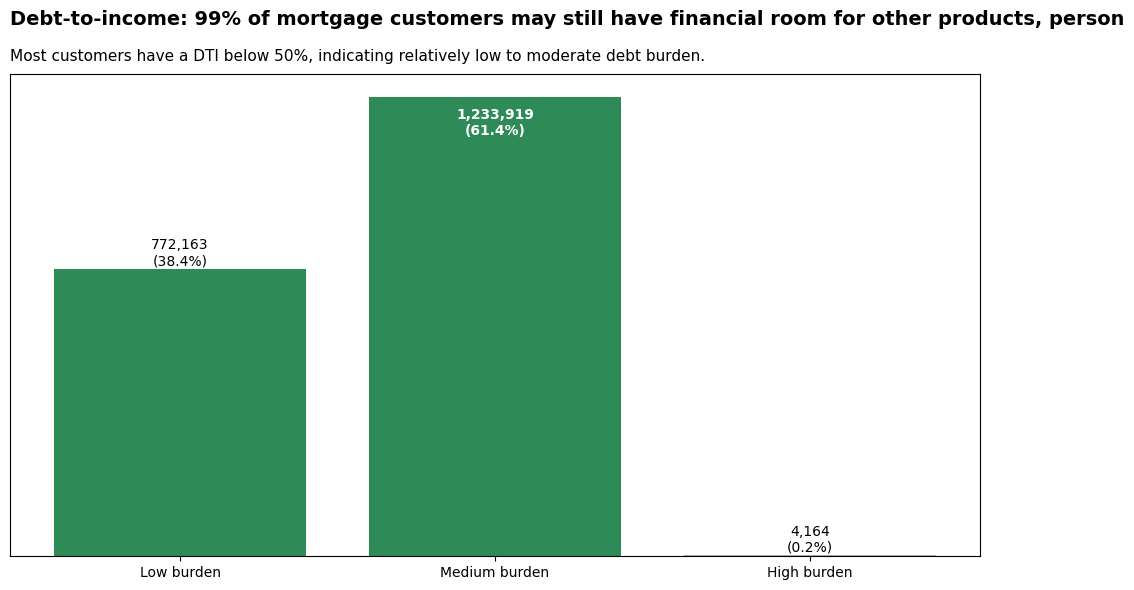

In [24]:
#3 CHART

# Count only the 3 DTI burden categories
counts = dataset.loc[
    dataset["dti_burden"].isin(
        ["Low burden", "Medium burden", "High burden"]
    ),
    "dti_burden"
].value_counts()

# Keep desired order
order = ["Low burden", "Medium burden", "High burden"]
counts = counts.reindex(order)

# Calculate percentage
percentages = counts / counts.sum() * 100

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Green for Low and Medium, gray for High
bar_colors = ["#2E8B57", "#2E8B57", "#B0B0B0"]

bars = ax.bar(
    counts.index,
    counts.values,
    color=bar_colors
)

# Title - left aligned
ax.set_title(
    "Debt-to-income: 99% of mortgage customers may still have financial room for other products, person",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=35
)

# Subtitle
ax.text(
    0,
    1.02,
    "Most customers have a DTI below 50%, indicating relatively low to moderate debt burden.",
    transform=ax.transAxes,
    fontsize=11,
    va="bottom"
)

# Remove Y-axis numbers, ticks, and 1e6
ax.tick_params(axis="y", left=False, labelleft=False)

# Add labels
for i, (bar, count, pct) in enumerate(
    zip(bars, counts.values, percentages.values)
):
    if counts.index[i] == "Medium burden":
        # Label inside the medium bar
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 30000,
            f"{count:,}\n({pct:.1f}%)",
            ha="center",
            va="top",
            color="white",
            fontweight="bold"
        )
    else:
        # Label above the bar
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{count:,}\n({pct:.1f}%)",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

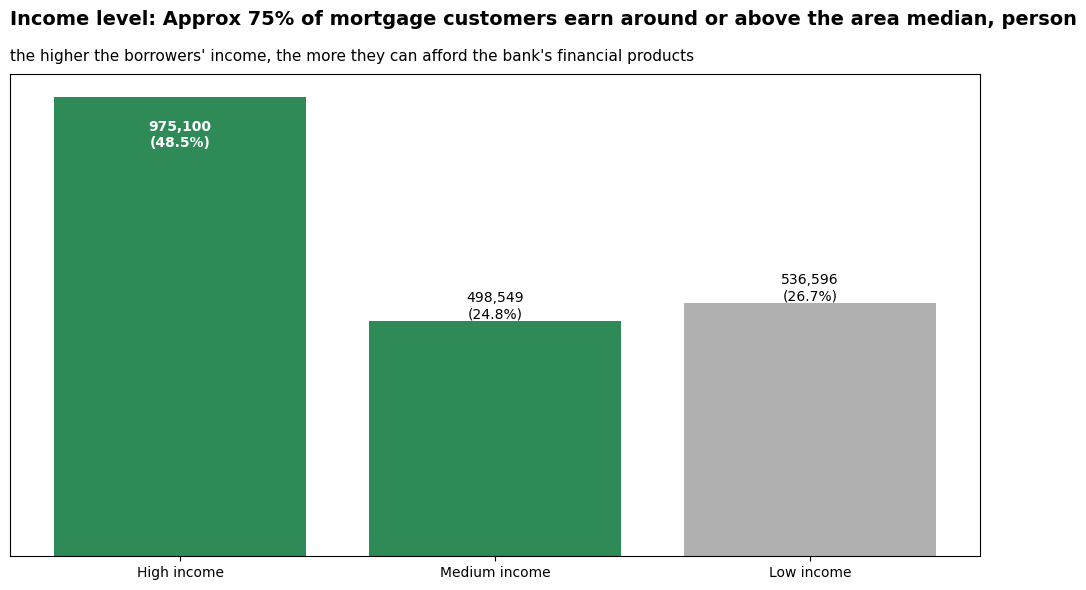

In [25]:
#4
#import matplotlib.pyplot as plt

# Count records
counts = dataset.groupby("income_category")["record_num_sf_ctf"].count()

# Desired order
order = ["High income", "Medium income", "Low income"]
counts = counts.reindex(order)

# Calculate percentage
percentages = counts / counts.sum() * 100

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

# High & Medium = green, Low = grey
bar_colors = ["#2E8B57", "#2E8B57", "#B0B0B0"]

bars = ax.bar(
    counts.index,
    counts.values,
    color=bar_colors
)

# Title
ax.set_title(
    "Income level: Approx 75% of mortgage customers earn around or above the area median, person",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=35
)

# Subtitle
ax.text(
    0,
    1.02,
    "the higher the borrowers' income, the more they can afford the bank's financial products",
    transform=ax.transAxes,
    fontsize=11,
    va="bottom"
)

# Remove Y-axis numbers and ticks
ax.tick_params(
    axis="y",
    left=False,
    labelleft=False
)

# Add labels
for i, (bar, count, pct) in enumerate(
    zip(bars, counts.values, percentages.values)
):
    
    if counts.index[i] == "High income":
        # INSIDE High income
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 0.95,
            f"{count:,}\n({pct:.1f}%)",
            ha="center",
            va="top",
            color="white",
            fontweight="bold"
        )
        
    else:
        # ABOVE Medium and Low
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{count:,}\n({pct:.1f}%)",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

In [26]:
dataset

,enterprise,record_num_sf_ctf,state_fips,cbsa_metro_code,county_fips,tract_2020,tract_minority_pct,tract_income_med,ami_local,tract_income_ratio,...,area_high_opp,tract_colonias,dti_cat_name,dti_burden,income_category,enterprise_name,fthb_name,borrower_type,age_category,term_category
0,2,20000001,48,19100,439,113932,51.83,141250,99957,1.4131,...,1,0,36 to less than 50 percent,Medium burden,High income,Freddie Mac,Not first time,With co-borrower,25–34,Long-term (20 years+)
1,2,20000002,48,19100,439,113946,46.18,114286,99957,1.1434,...,1,0,20 to less than 30 percent,Low burden,High income,Freddie Mac,First time,With co-borrower,35–44,Long-term (20 years+)
2,2,20000003,37,39580,183,52807,69.51,80605,113293,0.7115,...,0,0,36 to less than 50 percent,Medium burden,High income,Freddie Mac,Not first time,Single borrower,35–44,Long-term (20 years+)
3,2,20000004,42,38300,3,151700,23.83,114601,96434,1.1884,...,0,0,36 to less than 50 percent,Medium burden,Low income,Freddie Mac,Not first time,Single borrower,65–74,Long-term (20 years+)
4,2,20000005,17,16980,31,823001,35.67,69542,106055,0.6557,...,0,0,36 to less than 50 percent,Medium burden,Low income,Freddie Mac,Not first time,Single borrower,55–64,Medium-term
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010243,1,10982109,47,99999,35,970101,6.87,82699,66883,1.2365,...,1,0,36 to less than 50 percent,Medium burden,Low income,Fannie Mae,Not first time,With co-borrower,65–74,Medium-term
2010244,1,10982110,4,38060,13,112202,87.52,58182,93191,0.6243,...,0,0,36 to less than 50 percent,Medium burden,Low income,Fannie Mae,First time,Single borrower,Under 25,Long-term (20 years+)
2010245,1,10982111,26,19820,147,620000,35.11,49893,93779,0.5320,...,0,0,20 to less than 30 percent,Low burden,Low income,Fannie Mae,Not first time,Single borrower,45–54,Medium-term
2010246,1,10982112,25,12700,1,14900,11.33,131522,118599,1.1090,...,1,0,36 to less than 50 percent,Medium burden,Low income,Fannie Mae,Not first time,Single borrower,65–74,Long-term (20 years+)


In [27]:
# WHICH KIND OF MORTGAGE CUSTOMERS WE SHOULD BE FOCUSING ON

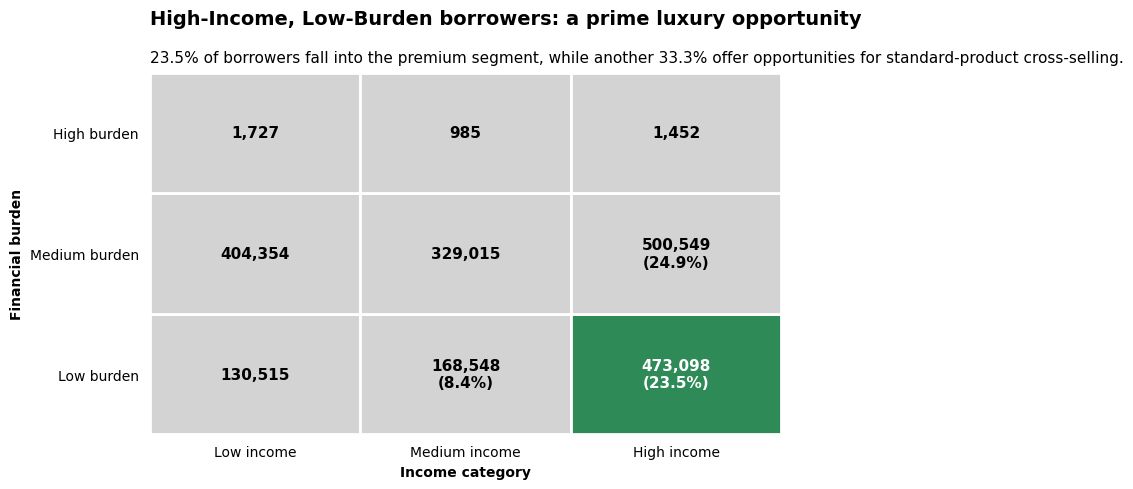

In [29]:
#5

#import pandas as pd
#import matplotlib.pyplot as plt

# --------------------------------
# Remove unavailable values
# --------------------------------

cross_data = dataset[
    (dataset["dti_burden"] != "Not available") &
    (dataset["income_category"] != "Not available")
].copy()


# --------------------------------
# Create cross-tabulation
# --------------------------------

cross_tab = pd.crosstab(
    cross_data["dti_burden"],
    cross_data["income_category"]
)


# --------------------------------
# Set desired order
# --------------------------------

dti_order = [
    "Low burden",
    "Medium burden",
    "High burden"
]

income_order = [
    "Low income",
    "Medium income",
    "High income"
]

cross_tab = cross_tab.reindex(
    index=dti_order,
    columns=income_order,
    fill_value=0
)


# --------------------------------
# Calculate % of GRAND TOTAL
# --------------------------------

grand_total = cross_tab.values.sum()

percent_of_total = (
    cross_tab / grand_total * 100
)


# --------------------------------
# Define colors
# --------------------------------

colors = []

for dti in dti_order:
    row_colors = []

    for income in income_order:

        # GREEN:
        # Low burden + High income
        if dti == "Low burden" and income == "High income":
            row_colors.append("#2E8B57")

        # YELLOW:
        # Low burden + Medium income
        # OR Medium burden + High income
        elif (
            (dti == "Low burden" and income == "Medium income") or
            (dti == "Medium burden" and income == "High income")
        ):
            row_colors.append("#D3D3D3")

        # GREY:
        else:
            row_colors.append("#D3D3D3")

    colors.append(row_colors)


# --------------------------------
# Create chart
# --------------------------------

fig, ax = plt.subplots(figsize=(10, 5))


# --------------------------------
# Draw cells
# --------------------------------

for i in range(len(dti_order)):
    for j in range(len(income_order)):

        value = cross_tab.iloc[i, j]
        percentage = percent_of_total.iloc[i, j]

        # Draw cell
        ax.add_patch(
            plt.Rectangle(
                (j, i),
                1,
                1,
                facecolor=colors[i][j],
                edgecolor="white",
                linewidth=2
            )
        )

        # --------------------------------
        # Only show % for GREEN and YELLOW
        # --------------------------------

        is_green = (
            dti_order[i] == "Low burden" and
            income_order[j] == "High income"
        )

        is_yellow = (
            (dti_order[i] == "Low burden" and
             income_order[j] == "Medium income")
            or
            (dti_order[i] == "Medium burden" and
             income_order[j] == "High income")
        )

        if is_green or is_yellow:

            text_color = "white" if is_green else "black"

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{value:,}\n({percentage:.1f}%)",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color=text_color
            )

        else:

            # Grey cells: count only
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{value:,}",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color="black"
            )


# --------------------------------
# Axis settings
# --------------------------------

ax.set_xlim(0, 3)
ax.set_ylim(0, 3)

ax.set_xticks([0.5, 1.5, 2.5])
ax.set_xticklabels(income_order)

ax.set_yticks([0.5, 1.5, 2.5])
ax.set_yticklabels(dti_order)

ax.set_xlabel(
    "Income category",
    fontweight="bold"
)

ax.set_ylabel(
    "Financial burden",
    fontweight="bold"
)


# --------------------------------
# Title & subtitle
# --------------------------------

ax.set_title(
    "High-Income, Low-Burden borrowers: a prime luxury opportunity",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=35
)

ax.text(
    0,
    1.02,
    "23.5% of borrowers fall into the premium segment, while another 33.3% offer opportunities for standard-product cross-selling.",
    transform=ax.transAxes,
    fontsize=11,
    va="bottom"
)


# --------------------------------
# Clean up
# --------------------------------

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0, pad=8)

plt.tight_layout()
plt.show()

In [ ]:
dataset.columns

In [ ]:
## WHO ARE WE FOCUSING ON ##

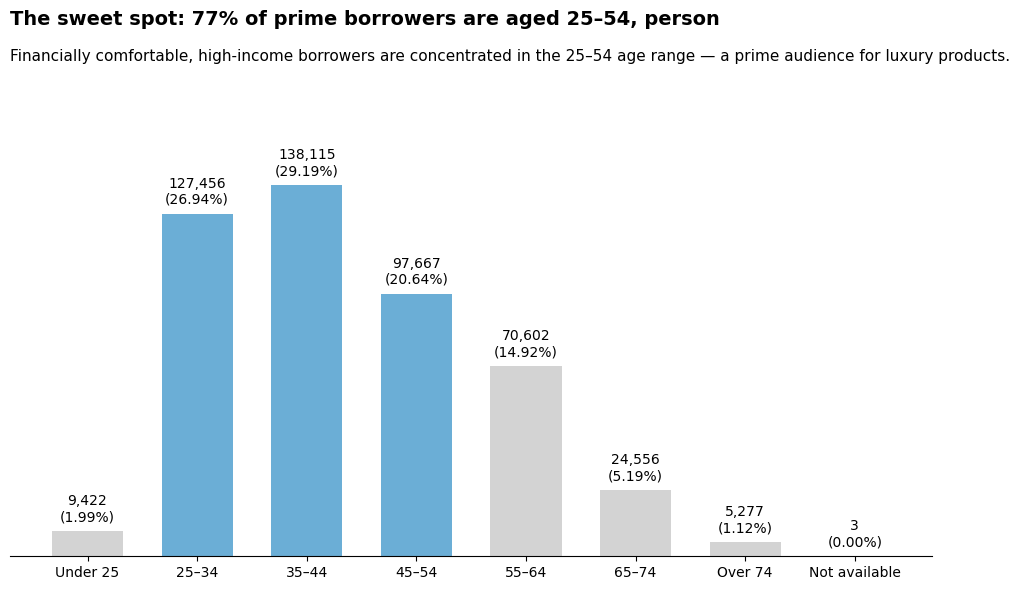

In [30]:
#6

#age profile
#import pandas as pd
#import matplotlib.pyplot as plt
 
income = pd.to_numeric(dataset["income_ratio"], errors="coerce")

dti = pd.to_numeric(dataset["dti_cat"], errors="coerce")
 
# Select low-DTI + high-income records

ages = dataset.loc[

    dti.isin([10, 20, 30])
& income.ge(1.20)
& income.lt(float("inf"))
& income.ne(9999),

    "age_category"

].fillna("Not available")
 
if ages.empty:

    raise ValueError("No records match the selected segment.")
 
# Use your existing age mapping

order = list(age_mapping.values())

counts = ages.value_counts().reindex(order, fill_value=0)
 
# Selected segment = 100%

grand_total = len(ages)

percentages = counts / grand_total * 100
 
# Highlight ages 25–54 in blue; other groups in grey

highlight_ages = {"25-34", "35-44", "45-54"}
 
colors = [

    "#6BAED6"

    if str(age).replace("–", "-").strip() in highlight_ages

    else "#D3D3D3"

    for age in counts.index

]
 
fig, ax = plt.subplots(figsize=(11, 6))
 
bars = ax.bar(

    counts.index,

    percentages,

    color=colors,

    width=0.65

)
 
ax.bar_label(

    bars,

    labels=[

        f"{count:,}\n({pct:.2f}%)"

        for count, pct in zip(counts, percentages)

    ],

    padding=5,

    fontsize=10

)
 
ax.set_ylim(0, percentages.max() * 1.30)

ax.set_xlabel("")

ax.set_ylabel("")

ax.tick_params(axis="y", left=False, labelleft=False)
 
# Left-aligned title

ax.set_title(

    "The sweet spot: 77% of prime borrowers are aged 25–54, person",

    loc="left",

    fontsize=14,

    fontweight="bold",

    pad=35

)
 
# Left-aligned subtitle

ax.text(

    0, 1.02,

    "Financially comfortable, high-income borrowers are concentrated in the 25–54 age range — a prime audience for luxury products.",

    transform=ax.transAxes,

    ha="left",

    va="bottom",

    fontsize=11

)
 
ax.spines[["top", "right", "left"]].set_visible(False)
 
plt.tight_layout()

plt.show()
 

In [31]:
## PRODUCTS WE CAN CROSS-SELL THESE PEOPLE##

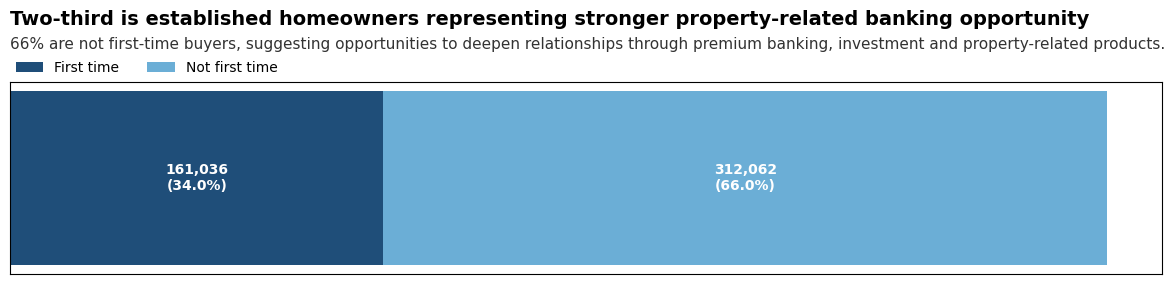

In [32]:
#7

#import pandas as pd
#import matplotlib.pyplot as plt

# Filter data
filtered_data = dataset[
    (dataset['dti_burden'] == 'Low burden') &
    (dataset['income_category'] == 'High income')
]

# Count records by first-time homebuyer status
count_data = filtered_data.groupby(
    'fthb_name'
)['record_num_sf_ctf'].count()

# Calculate percentage
percentage = count_data / count_data.sum() * 100

# Create chart
fig, ax = plt.subplots(figsize=(12, 3))

# Colors
colors = ['#1F4E79', '#6BAED6']

left = 0

for i, (category, value) in enumerate(count_data.items()):

    percent = percentage[category]

    ax.barh(
        y=['Borrowers'],
        width=[value],
        left=left,
        color=colors[i],
        label=category
    )

    # Labels inside bars
    if percent > 5:
        ax.text(
            left + value / 2,
            0,
            f'{value:,}\n({percent:.1f}%)',
            ha='center',
            va='center',
            fontweight='bold',
            color='white'
        )

    left += value


# --------------------------------
# Title
# --------------------------------

fig.text(
    0.02,
    0.96,
    'Two-third is established homeowners representing stronger property-related banking opportunity',
    fontsize=14,
    fontweight='bold',
    ha='left',
    va='top'
)


# --------------------------------
# Subtitle
# --------------------------------

fig.text(
    0.02,
    0.87,
    "66% are not first-time buyers, suggesting opportunities to deepen relationships through premium banking, investment and property-related products.",
    fontsize=11,
    color='#333333',
    ha='left',
    va='top'
)


# --------------------------------
# Legend
# FAR LEFT, SAME ALIGNMENT AS TITLE
# --------------------------------

fig.legend(
    loc='upper left',
    bbox_to_anchor=(0.02, 0.81),
    ncol=2,
    frameon=False,
    borderaxespad=0
)


# --------------------------------
# Remove axes labels/ticks
# --------------------------------

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlabel('')


# --------------------------------
# Adjust chart position
# --------------------------------

plt.subplots_adjust(
    top=0.72,
    left=0.02,
    right=0.98,
    bottom=0.08
)

plt.show()

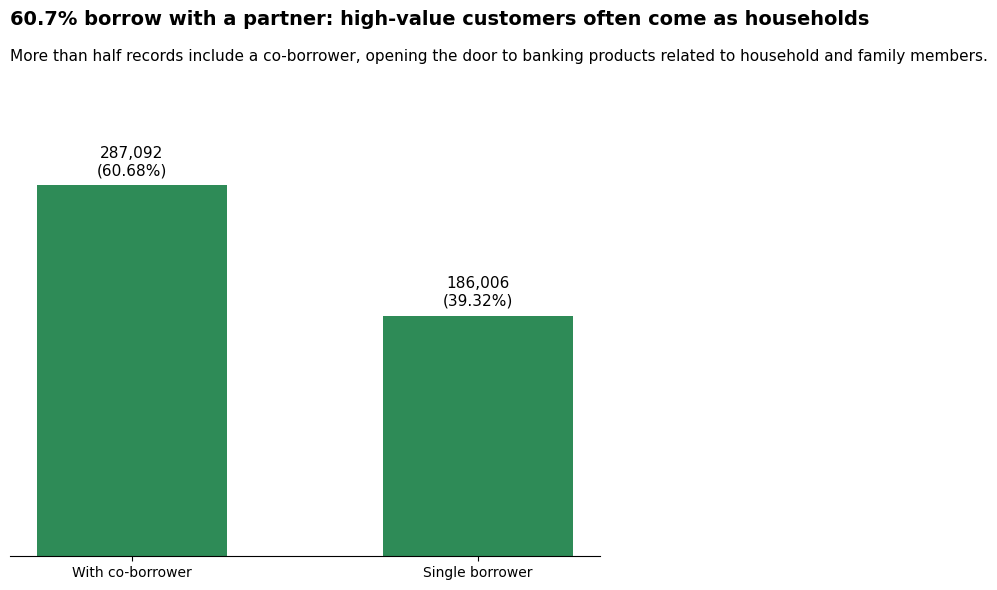

In [33]:
#8

#import pandas as pd
#import matplotlib.pyplot as plt
 
income = pd.to_numeric(dataset["income_ratio"], errors="coerce")
dti = pd.to_numeric(dataset["dti_cat"], errors="coerce")
 
segment = dataset.loc[
    dti.isin([10, 20, 30])
& income.ge(1.20)
& income.lt(float("inf"))
& income.ne(9999)
].copy()
 
if segment.empty:
    raise ValueError("No records match the selected segment.")
 
order = ["With co-borrower", "Single borrower"]
 
counts = (
    segment["borrower_type"]
    .value_counts()
    .reindex(order, fill_value=0)
)
 
grand_total = len(segment)
percentages = counts / grand_total * 100
 
fig, ax = plt.subplots(figsize=(9, 6))
 
bars = ax.bar(
    counts.index,
    percentages,
    color=["#2E8B57"],
    width=0.55
)
 
ax.bar_label(
    bars,
    labels=[
        f"{count:,}\n({pct:.2f}%)"
        for count, pct in zip(counts, percentages)
    ],
    padding=5,
    fontsize=11
)
 
ax.set_ylim(0, percentages.max() * 1.30)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", left=False, labelleft=False)
 
# Left-aligned title
ax.set_title(
    "60.7% borrow with a partner: high-value customers often come as households",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=35
)
 
# Left-aligned subtitle
ax.text(
    0, 1.02,
    "More than half records include a co-borrower, opening the door to banking products related to household and family members.",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=11
)
 
ax.spines[["top", "right", "left"]].set_visible(False)
 
plt.tight_layout()
plt.show()

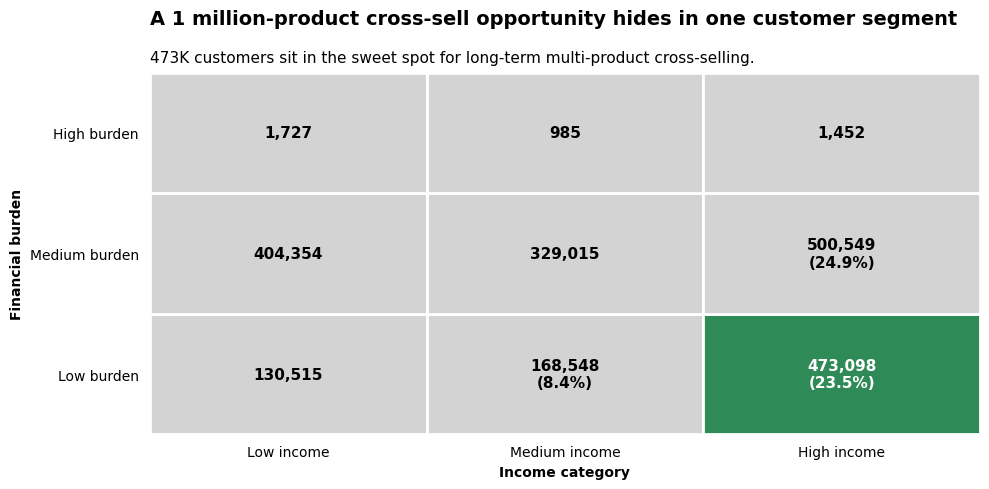

In [39]:
#5

#import pandas as pd
#import matplotlib.pyplot as plt

# --------------------------------
# Remove unavailable values
# --------------------------------

cross_data = dataset[
    (dataset["dti_burden"] != "Not available") &
    (dataset["income_category"] != "Not available")
].copy()


# --------------------------------
# Create cross-tabulation
# --------------------------------

cross_tab = pd.crosstab(
    cross_data["dti_burden"],
    cross_data["income_category"]
)


# --------------------------------
# Set desired order
# --------------------------------

dti_order = [
    "Low burden",
    "Medium burden",
    "High burden"
]

income_order = [
    "Low income",
    "Medium income",
    "High income"
]

cross_tab = cross_tab.reindex(
    index=dti_order,
    columns=income_order,
    fill_value=0
)


# --------------------------------
# Calculate % of GRAND TOTAL
# --------------------------------

grand_total = cross_tab.values.sum()

percent_of_total = (
    cross_tab / grand_total * 100
)


# --------------------------------
# Define colors
# --------------------------------

colors = []

for dti in dti_order:
    row_colors = []

    for income in income_order:

        # GREEN:
        # Low burden + High income
        if dti == "Low burden" and income == "High income":
            row_colors.append("#2E8B57")

        # YELLOW:
        # Low burden + Medium income
        # OR Medium burden + High income
        elif (
            (dti == "Low burden" and income == "Medium income") or
            (dti == "Medium burden" and income == "High income")
        ):
            row_colors.append("#D3D3D3")

        # GREY:
        else:
            row_colors.append("#D3D3D3")

    colors.append(row_colors)


# --------------------------------
# Create chart
# --------------------------------

fig, ax = plt.subplots(figsize=(10, 5))


# --------------------------------
# Draw cells
# --------------------------------

for i in range(len(dti_order)):
    for j in range(len(income_order)):

        value = cross_tab.iloc[i, j]
        percentage = percent_of_total.iloc[i, j]

        # Draw cell
        ax.add_patch(
            plt.Rectangle(
                (j, i),
                1,
                1,
                facecolor=colors[i][j],
                edgecolor="white",
                linewidth=2
            )
        )

        # --------------------------------
        # Only show % for GREEN and YELLOW
        # --------------------------------

        is_green = (
            dti_order[i] == "Low burden" and
            income_order[j] == "High income"
        )

        is_yellow = (
            (dti_order[i] == "Low burden" and
             income_order[j] == "Medium income")
            or
            (dti_order[i] == "Medium burden" and
             income_order[j] == "High income")
        )

        if is_green or is_yellow:

            text_color = "white" if is_green else "black"

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{value:,}\n({percentage:.1f}%)",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color=text_color
            )

        else:

            # Grey cells: count only
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{value:,}",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color="black"
            )


# --------------------------------
# Axis settings
# --------------------------------

ax.set_xlim(0, 3)
ax.set_ylim(0, 3)

ax.set_xticks([0.5, 1.5, 2.5])
ax.set_xticklabels(income_order)

ax.set_yticks([0.5, 1.5, 2.5])
ax.set_yticklabels(dti_order)

ax.set_xlabel(
    "Income category",
    fontweight="bold"
)

ax.set_ylabel(
    "Financial burden",
    fontweight="bold"
)


# --------------------------------
# Title & subtitle
# --------------------------------

ax.set_title(
    "A 1 million-product cross-sell opportunity hides in one customer segment",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=35
)

ax.text(
    0,
    1.02,
    "473K customers sit in the sweet spot for long-term multi-product cross-selling.",
    transform=ax.transAxes,
    fontsize=11,
    va="bottom"
)


# --------------------------------
# Clean up
# --------------------------------

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0, pad=8)

plt.tight_layout()
plt.show()